In [400]:
import yfinance as yf
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn import linear_model
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

In [401]:
df = yf.download('AAPL', '2019-01-01', '2025-06-04')
df.columns = df.columns.get_level_values(0)
df.head


[*********************100%***********************]  1 of 1 completed


<bound method NDFrame.head of Price            Close        High         Low        Open     Volume
Date                                                                 
2019-01-02   37.503719   37.724583   36.627397   36.784138  148158800
2019-01-03   33.768089   34.606413   33.722966   34.193187  365248800
2019-01-04   35.209610   35.278483   34.150426   34.323790  234428400
2019-01-07   35.131245   35.344984   34.649149   35.314110  219111200
2019-01-08   35.800945   36.055057   35.271354   35.518337  164101200
...                ...         ...         ...         ...        ...
2025-05-28  199.811966  202.114955  199.293539  199.981448   45339700
2025-05-29  199.343369  203.191658  197.907735  202.962360   51396800
2025-05-30  200.240662  201.347295  196.183002  198.765141   70819900
2025-06-02  201.088074  201.516777  199.512865  199.672384   35423300
2025-06-03  202.653320  203.151803  200.350331  200.739147   46381600

[1614 rows x 5 columns]>

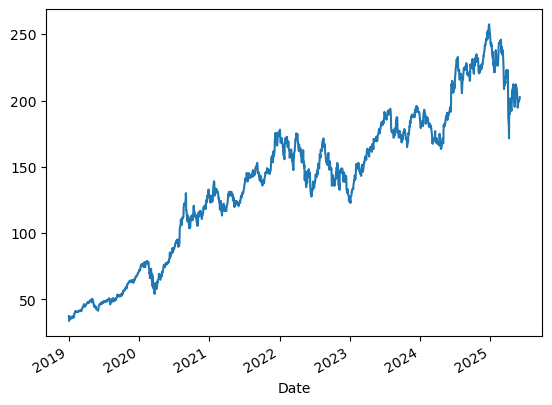

In [402]:
df["Close"].plot()
plt.show()

In [403]:
df['Percentage Change'] = ((df['Close'] - df['Close'].shift(1))/(df['Close']).shift(1) * 100)
df


Price,Close,High,Low,Open,Volume,Percentage Change
Date,,,,,,
2019-01-02,37.503719,37.724583,36.627397,36.784138,148158800,NaN
2019-01-03,33.768089,34.606413,33.722966,34.193187,365248800,-9.960692
2019-01-04,35.209610,35.278483,34.150426,34.323790,234428400,4.268884
2019-01-07,35.131245,35.344984,34.649149,35.314110,219111200,-0.222568
2019-01-08,35.800945,36.055057,35.271354,35.518337,164101200,1.906282
...,...,...,...,...,...,...
2025-05-28,199.811966,202.114955,199.293539,199.981448,45339700,0.104891
2025-05-29,199.343369,203.191658,197.907735,202.962360,51396800,-0.234519
2025-05-30,200.240662,201.347295,196.183002,198.765141,70819900,0.450124


In [404]:
df['Moving Average'] = df['Close'].rolling(window=5).mean()
df

Price,Close,High,Low,Open,Volume,Percentage Change,Moving Average
Date,,,,,,,
2019-01-02,37.503719,37.724583,36.627397,36.784138,148158800,NaN,NaN
2019-01-03,33.768089,34.606413,33.722966,34.193187,365248800,-9.960692,NaN
2019-01-04,35.209610,35.278483,34.150426,34.323790,234428400,4.268884,NaN
2019-01-07,35.131245,35.344984,34.649149,35.314110,219111200,-0.222568,NaN
2019-01-08,35.800945,36.055057,35.271354,35.518337,164101200,1.906282,35.482722
...,...,...,...,...,...,...,...
2025-05-28,199.811966,202.114955,199.293539,199.981448,45339700,0.104891,199.263629
2025-05-29,199.343369,203.191658,197.907735,202.962360,51396800,-0.234519,198.836923
2025-05-30,200.240662,201.347295,196.183002,198.765141,70819900,0.450124,198.735233


In [405]:
conditions = [
    (df['Close'].shift(-1) > df['Close']),
    (df['Close'].shift(-1) < df['Close'])
]
values = [1,0]
df['Target'] = np.select(conditions, values)
df

Price,Close,High,Low,Open,Volume,Percentage Change,Moving Average,Target
Date,,,,,,,,
2019-01-02,37.503719,37.724583,36.627397,36.784138,148158800,NaN,NaN,0
2019-01-03,33.768089,34.606413,33.722966,34.193187,365248800,-9.960692,NaN,1
2019-01-04,35.209610,35.278483,34.150426,34.323790,234428400,4.268884,NaN,0
2019-01-07,35.131245,35.344984,34.649149,35.314110,219111200,-0.222568,NaN,1
2019-01-08,35.800945,36.055057,35.271354,35.518337,164101200,1.906282,35.482722,1
...,...,...,...,...,...,...,...,...
2025-05-28,199.811966,202.114955,199.293539,199.981448,45339700,0.104891,199.263629,0
2025-05-29,199.343369,203.191658,197.907735,202.962360,51396800,-0.234519,198.836923,1
2025-05-30,200.240662,201.347295,196.183002,198.765141,70819900,0.450124,198.735233,1


In [406]:
df['Price Momentum'] = ((df['Close'] - df['Close'].shift(10)) / (df['Close']).shift(10)   * 100)
df.dropna(inplace=True)
df

Price,Close,High,Low,Open,Volume,Percentage Change,Moving Average,Target,Price Momentum
Date,,,,,,,,,
2019-01-16,36.796017,37.019254,36.335294,36.354293,122278800,1.221678,36.292548,1,-1.887020
2019-01-17,37.014511,37.441986,36.397047,36.620284,119284800,0.593799,36.390393,1,9.613875
2019-01-18,37.242489,37.494223,37.042998,37.403977,135004000,0.615915,36.605554,0,5.773648
2019-01-22,36.406551,37.221125,36.245059,37.145132,121576000,-2.244580,36.762296,1,3.630121
2019-01-23,36.553787,36.843520,36.026569,36.608408,92522400,0.404421,36.802671,0,2.102855
...,...,...,...,...,...,...,...,...,...
2025-05-28,199.811966,202.114955,199.293539,199.981448,45339700,0.104891,199.263629,0,-5.875163
2025-05-29,199.343369,203.191658,197.907735,202.962360,51396800,-0.234519,198.836923,1,-5.830553
2025-05-30,200.240662,201.347295,196.183002,198.765141,70819900,0.450124,198.735233,1,-5.013005


In [407]:
df.dropna(inplace=True)
df.drop(df.tail(1).index, inplace=True)
df


Price,Close,High,Low,Open,Volume,Percentage Change,Moving Average,Target,Price Momentum
Date,,,,,,,,,
2019-01-16,36.796017,37.019254,36.335294,36.354293,122278800,1.221678,36.292548,1,-1.887020
2019-01-17,37.014511,37.441986,36.397047,36.620284,119284800,0.593799,36.390393,1,9.613875
2019-01-18,37.242489,37.494223,37.042998,37.403977,135004000,0.615915,36.605554,0,5.773648
2019-01-22,36.406551,37.221125,36.245059,37.145132,121576000,-2.244580,36.762296,1,3.630121
2019-01-23,36.553787,36.843520,36.026569,36.608408,92522400,0.404421,36.802671,0,2.102855
...,...,...,...,...,...,...,...,...,...
2025-05-27,199.602600,200.130991,196.831020,197.698391,56288500,2.529841,200.547720,1,-5.019204
2025-05-28,199.811966,202.114955,199.293539,199.981448,45339700,0.104891,199.263629,0,-5.875163
2025-05-29,199.343369,203.191658,197.907735,202.962360,51396800,-0.234519,198.836923,1,-5.830553


In [408]:
X = df[[
    'Volume',
    'Percentage Change',
    'Moving Average',
    'Price Momentum'
]] 

y = df['Target'].values



In [409]:
X_Train, X_Test, y_Train, y_Test = train_test_split(X, y, test_size=0.2, shuffle=False)

Logistic Regression Model

In [410]:
model = linear_model.LogisticRegression()
model.fit(X_Train, y_Train)
predictions = model.predict(X_Test)
accuracy = accuracy_score(predictions, y_Test)
print("Predictions: ", predictions)
print("Actual: ", y_Test)
print("Baseline Accuaracy: ", accuracy )


Predictions:  [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
Actual:  [1 0 0 1 0 0 0 0 0 0 0 1 1 1 0 1 0 1 1 1 0 1 0 0 1 0 0 0 1 0 1 0 1 0 1 1 0
 0 0 0 0 1 1 1 1 0 1 0 0 1 1 0 1 1 1 0 1 1 1 1 1 1 1 0 0 1 1 1 1 1 1 1 1 0
 1 0 1 1 1 0 1 0 0 0 1 1 1 1 0 1 1 1 1 1 1 1 0 1 1 1 0 0 1 0 1 0 0 1 1 1 1
 0 1 0 0 1 1 1 1 1 1 1 1 0 1 0 0 1 1 1 0 1 0 0 0 1 0 1 0 1 1 0 0 1 1 1 0 0
 1 0 1 1 1 0 1 0 1 0 1 1 

In [411]:
cm = confusion_matrix(y_Test, predictions)
cm

array([[  0, 141],
       [  0, 180]])

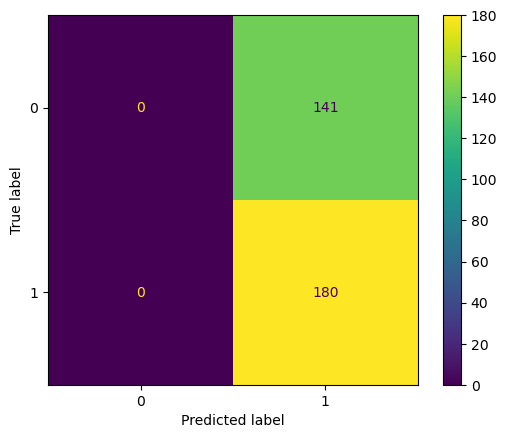

In [412]:
ConfusionMatrixDisplay.from_predictions(y_Test, predictions)
plt.show()

In [413]:
scaler = StandardScaler()
scaled_X_Train = scaler.fit_transform(X_Train)
scaled_X_Test = scaler.transform(X_Test)
new_Model = linear_model.LogisticRegression()
new_Model.fit(scaled_X_Train, y_Train)
predictions = new_Model.predict(scaled_X_Test)
accuracy = accuracy_score(predictions, y_Test)
print("Predictions: ", predictions)
print("Actual: ", y_Test)
print("Scaled Accuaracy: ", accuracy )

Predictions:  [0 0 1 1 0 1 0 1 1 1 1 0 0 0 0 1 0 0 0 0 0 1 0 1 1 0 1 1 1 0 1 1 1 0 1 0 0
 1 1 1 1 1 0 0 0 0 1 0 1 1 0 0 1 0 0 0 1 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0
 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0
 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0
 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 1 1 1 0 1 0 0 0 1 0 1 0 0 0 0
 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0]
Actual:  [1 0 0 1 0 0 0 0 0 0 0 1 1 1 0 1 0 1 1 1 0 1 0 0 1 0 0 0 1 0 1 0 1 0 1 1 0
 0 0 0 0 1 1 1 1 0 1 0 0 1 1 0 1 1 1 0 1 1 1 1 1 1 1 0 0 1 1 1 1 1 1 1 1 0
 1 0 1 1 1 0 1 0 0 0 1 1 1 1 0 1 1 1 1 1 1 1 0 1 1 1 0 0 1 0 1 0 0 1 1 1 1
 0 1 0 0 1 1 1 1 1 1 1 1 0 1 0 0 1 1 1 0 1 0 0 0 1 0 1 0 1 1 0 0 1 1 1 0 0
 1 0 1 1 1 0 1 0 1 0 1 1 

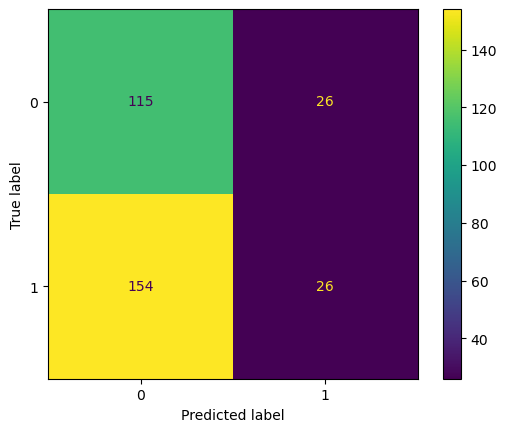

In [414]:
ConfusionMatrixDisplay.from_predictions(y_Test, predictions)
plt.show()

Random Forrest Model

In [415]:
forrestModel = RandomForestClassifier(n_estimators=100)
forrestModel.fit(X_Train, y_Train)
forrest_predictions = forrestModel.predict(X_Test)
forrest_accuracy = accuracy_score(forrest_predictions, y_Test)
print('Accuracy: ', forrest_accuracy)
print("Predictions: ", forrest_predictions)
print("Actual: ", y_Test)


Accuracy:  0.4797507788161994
Predictions:  [1 1 0 1 1 0 1 1 0 0 1 1 1 1 1 1 1 1 0 1 1 0 1 1 0 0 0 1 1 1 1 1 0 1 1 0 1
 0 0 1 1 0 0 1 0 1 1 0 0 0 1 0 1 0 1 1 1 1 1 0 1 1 0 0 0 0 0 1 1 0 0 1 1 1
 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 1 0 0 1 0 1 1 0 0 0 1 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 1 0 0 0 0 1 0 0 0 1 1 0 0 0 0 0 0 0 0 1 1 0 0 1 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0
 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
Actual:  [1 0 0 1 0 0 0 0 0 0 0 1 1 1 0 1 0 1 1 1 0 1 0 0 1 0 0 0 1 0 1 0 1 0 1 1 0
 0 0 0 0 1 1 1 1 0 1 0 0 1 1 0 1 1 1 0 1 1 1 1 1 1 1 0 0 1 1 1 1 1 1 1 1 0
 1 0 1 1 1 0 1 0 0 0 1 1 1 1 0 1 1 1 1 1 1 1 0 1 1 1 0 0 1 0 1 0 0 1 1 1 1
 0 1 0 0 1 1 1 1 1 1 1 1 0 1 0 0 1 1 1 0 1 0 0 0 1 0 1 0 1 1 0 0 1 1 1

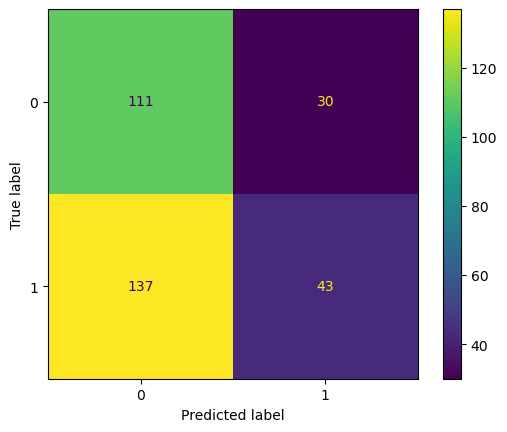

In [416]:
ConfusionMatrixDisplay.from_predictions(y_Test, forrest_predictions)